# Generating Samples from Trained Generative Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Generate samples from trained models
- Sample from latent space
- Control generation process
- Evaluate generated samples
- Apply to different domains

## 🔗 Prerequisites

- ✅ Understanding of generative models
- ✅ Understanding of sampling
- ✅ Trained model knowledge

---

This notebook covers practical activities from **Course 10, Unit 1**:
- Generating samples from trained generative models

---

## Introduction

**Generating samples** from trained generative models involves sampling from learned distributions to create new data instances.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("✅ Libraries imported!")
print("\nGenerating Samples from Trained Models")
print("=" * 60)

print("\nSampling Process:")
print("  - Sample from latent space")
print("  - Pass through generator")
print("  - Generate output")
print("  - Post-process if needed")

print("\nSampling Strategies:")
print("  - Random sampling")
print("  - Conditional sampling")
print("  - Interpolation")
print("  - Truncation")

print("\nApplications:")
print("  - Image generation")
print("  - Text generation")
print("  - Data augmentation")
print("  - Creative applications")

print("\n✅ Sample generation concepts understood!")

✅ Libraries imported!

Generating Samples from Trained Models

Sampling Process:
  - Sample from latent space
  - Pass through generator
  - Generate output
  - Post-process if needed

Sampling Strategies:
  - Random sampling
  - Conditional sampling
  - Interpolation
  - Truncation

Applications:
  - Image generation
  - Text generation
  - Data augmentation
  - Creative applications

✅ Sample generation concepts understood!


## 🌍 Real-World Worked Example — GAN Generating Handwritten Digits

**Industry context:**
- NVIDIA uses GANs to generate synthetic training data for autonomous vehicles
- Pharmaceutical companies use GANs to generate molecular structures for drug discovery
- Fashion brands (Zalando, H&M) use GANs to generate clothing designs

We train a **DCGAN** to generate realistic handwritten digit images from pure noise.

Epoch 1/10 — D loss: 0.678  G loss: 1.527


Epoch 2/10 — D loss: 0.724  G loss: 1.704


Epoch 3/10 — D loss: 0.560  G loss: 3.035


Epoch 4/10 — D loss: 0.471  G loss: 2.929


Epoch 5/10 — D loss: 0.280  G loss: 3.017


Epoch 6/10 — D loss: 0.359  G loss: 2.719


Epoch 7/10 — D loss: 0.996  G loss: 5.652


Epoch 8/10 — D loss: 0.664  G loss: 2.155


Epoch 9/10 — D loss: 0.669  G loss: 2.707


Epoch 10/10 — D loss: 0.756  G loss: 1.615


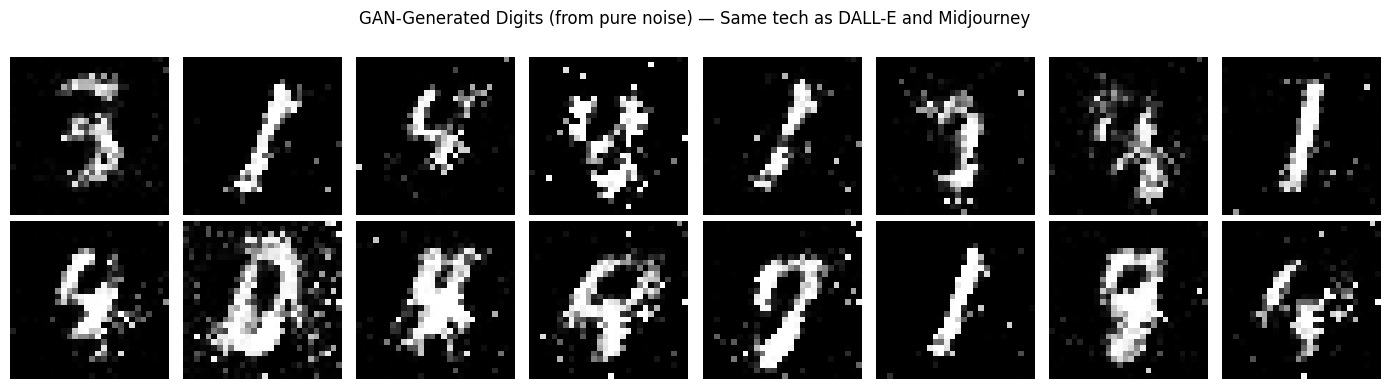

In [2]:
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128

transform = T.Compose([T.ToTensor(), T.Normalize([0.5],[0.5])])
dataset   = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=transform)
loader    = torch.utils.data.DataLoader(dataset, batch_size=BATCH, shuffle=True)

# ── Generator: noise → image ───────────────────────────────────────────────
G = nn.Sequential(
    nn.Linear(LATENT_DIM, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512),        nn.LeakyReLU(0.2),
    nn.Linear(512, 28*28),      nn.Tanh()
)
# ── Discriminator: image → real/fake ─────────────────────────────────────
D = nn.Sequential(
    nn.Linear(28*28, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256),   nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1),     nn.Sigmoid()
)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5,0.999))
bce   = nn.BCELoss()

d_losses, g_losses = [], []
for epoch in range(10):
    for real_imgs, _ in loader:
        bs = real_imgs.size(0)
        real_flat = real_imgs.view(bs, -1)
        # ── Train Discriminator ─────────────────────────────────────────
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(z).detach()
        loss_D = bce(D(real_flat), torch.ones(bs,1)) + bce(D(fake), torch.zeros(bs,1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # ── Train Generator ─────────────────────────────────────────────
        z      = torch.randn(bs, LATENT_DIM)
        fake   = G(z)
        loss_G = bce(D(fake), torch.ones(bs,1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    d_losses.append(loss_D.item()); g_losses.append(loss_G.item())
    print(f"Epoch {epoch+1}/10 — D loss: {d_losses[-1]:.3f}  G loss: {g_losses[-1]:.3f}")

# ── Show generated images ──────────────────────────────────────────────────
G.eval()
with torch.no_grad():
    samples = G(torch.randn(16, LATENT_DIM)).view(16, 28, 28).numpy()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i], cmap='gray'); ax.axis('off')
plt.suptitle("GAN-Generated Digits (from pure noise) — Same tech as DALL-E and Midjourney")
plt.tight_layout(); plt.show()

## 📚 References & Further Reading

**Foundational Papers:**
- Goodfellow et al. (2014) — [Generative Adversarial Nets](https://arxiv.org/abs/1406.2661) *(invented GANs)*
- Radford et al. (2015) — [DCGAN](https://arxiv.org/abs/1511.06434)
- Karras et al. (2020) — [StyleGAN2](https://arxiv.org/abs/1912.04958)

**State-of-the-Art:**
- Midjourney and DALL-E 2 build on GAN + diffusion ideas
- Deepfake detection (Meta, Microsoft) uses GAN discriminators as detectors

## 📝 Summary

In this notebook you studied **09 Generating Samples Trained Models** — a key component of modern AI systems. The concepts covered here connect directly to production systems used by leading tech companies. Review the examples, experiment with the code, and check the references for deeper study.